Clim stats: mean=895.57  std=841.56 mm/yr
  loaded member 0  (best val epoch 150  val=7.09386)
  loaded member 1  (best val epoch 84  val=1.21713)
  loaded member 2  (best val epoch 69  val=2.62479)
  loaded member 3  (best val epoch 42  val=8.68217)
  loaded member 4  (best val epoch 76  val=20.75762)

Loading evaluation data...
  AMIP BCC-CSM2-MR
  AMIP CESM2
  AMIP CNRM-CM6-1
  AMIP CanESM5
  AMIP E3SM-1-0
  AMIP GFDL-CM4
  AMIP HadGEM3-GC31-LL
  AMIP IPSL-CM6A-LR
  AMIP MIROC6
  AMIP MRI-ESM2-0
  AMIP TaiESM1
  HadGEM3-PPE (3 random members, x0=zero)
Total eval examples: 14

Generating per-example diagnostics...


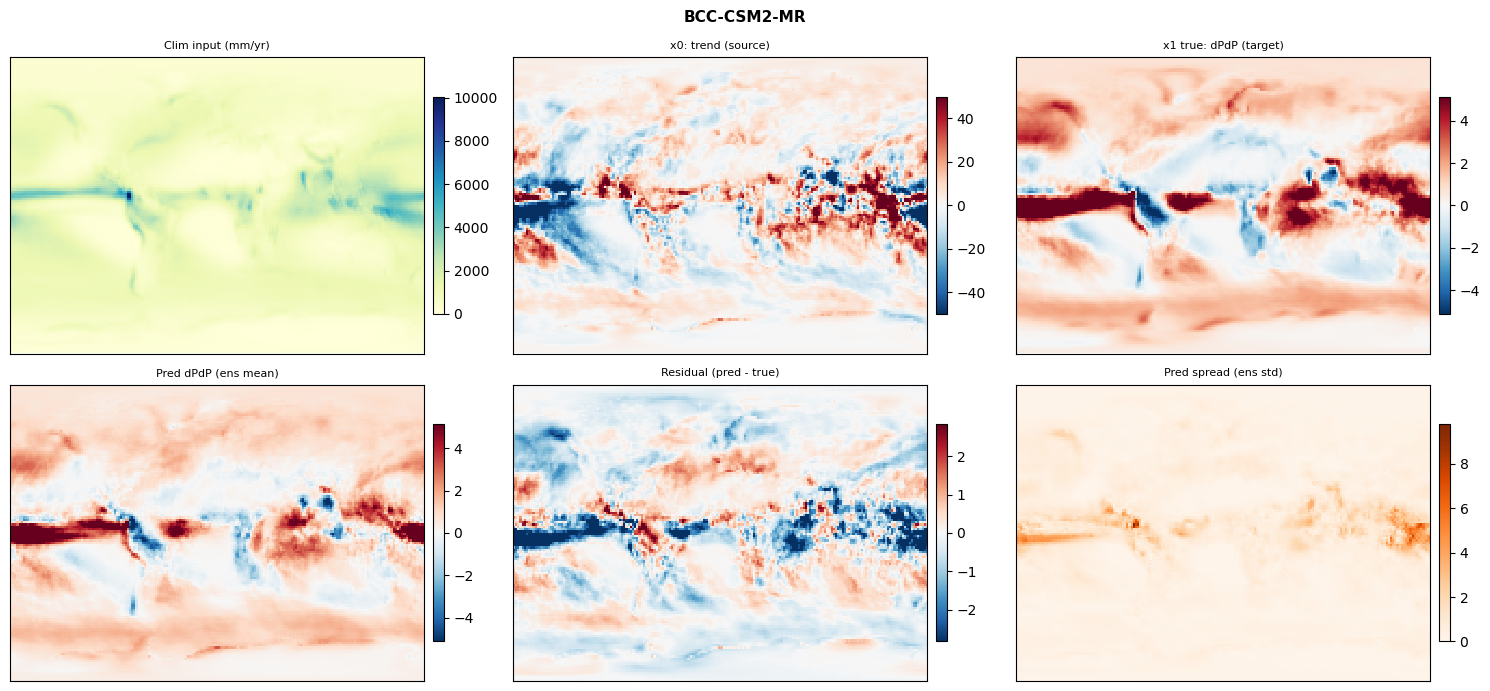

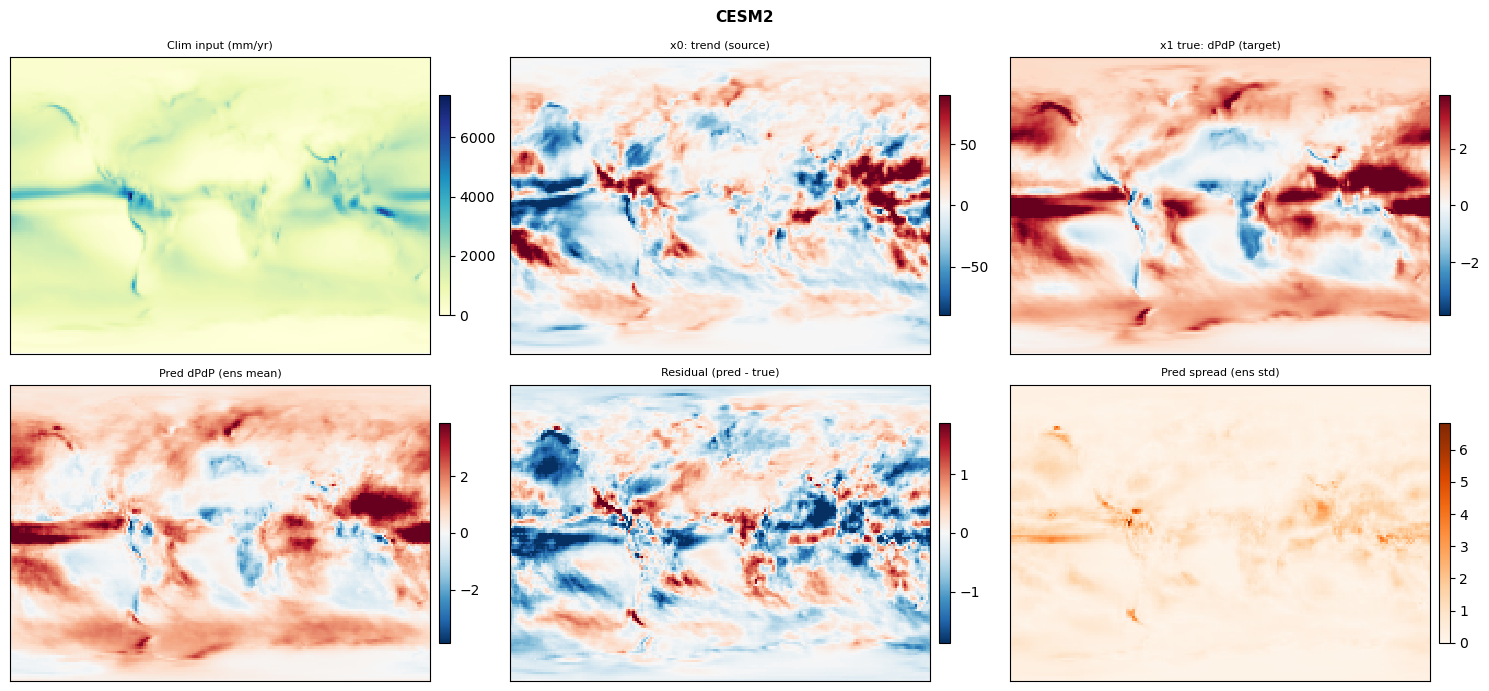

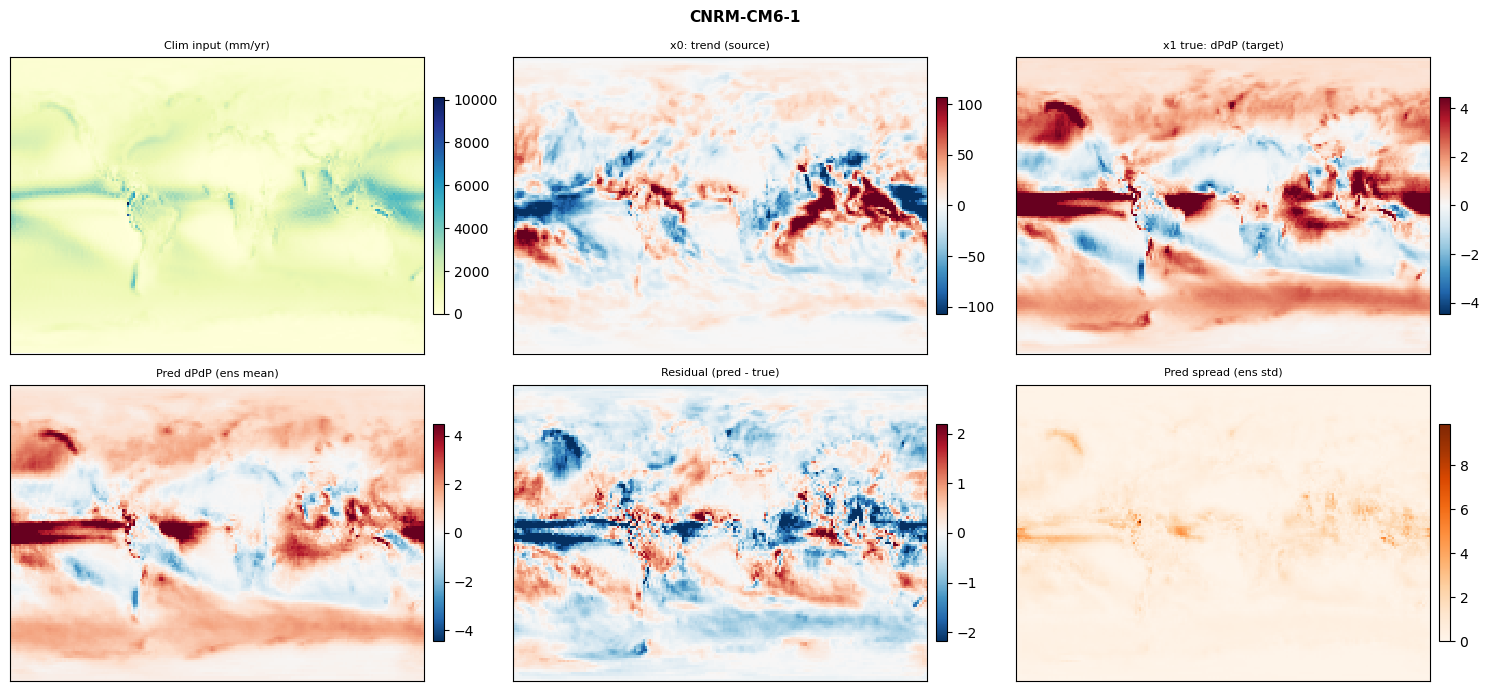

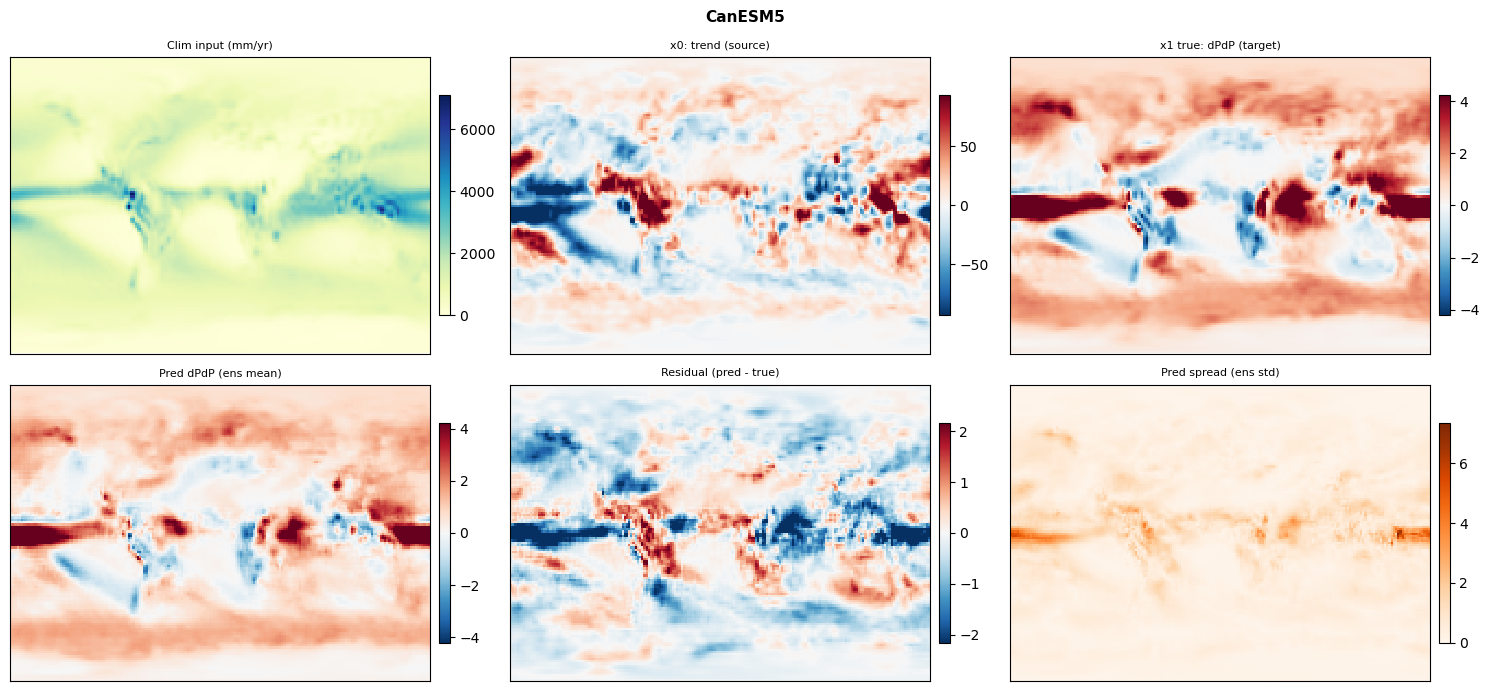

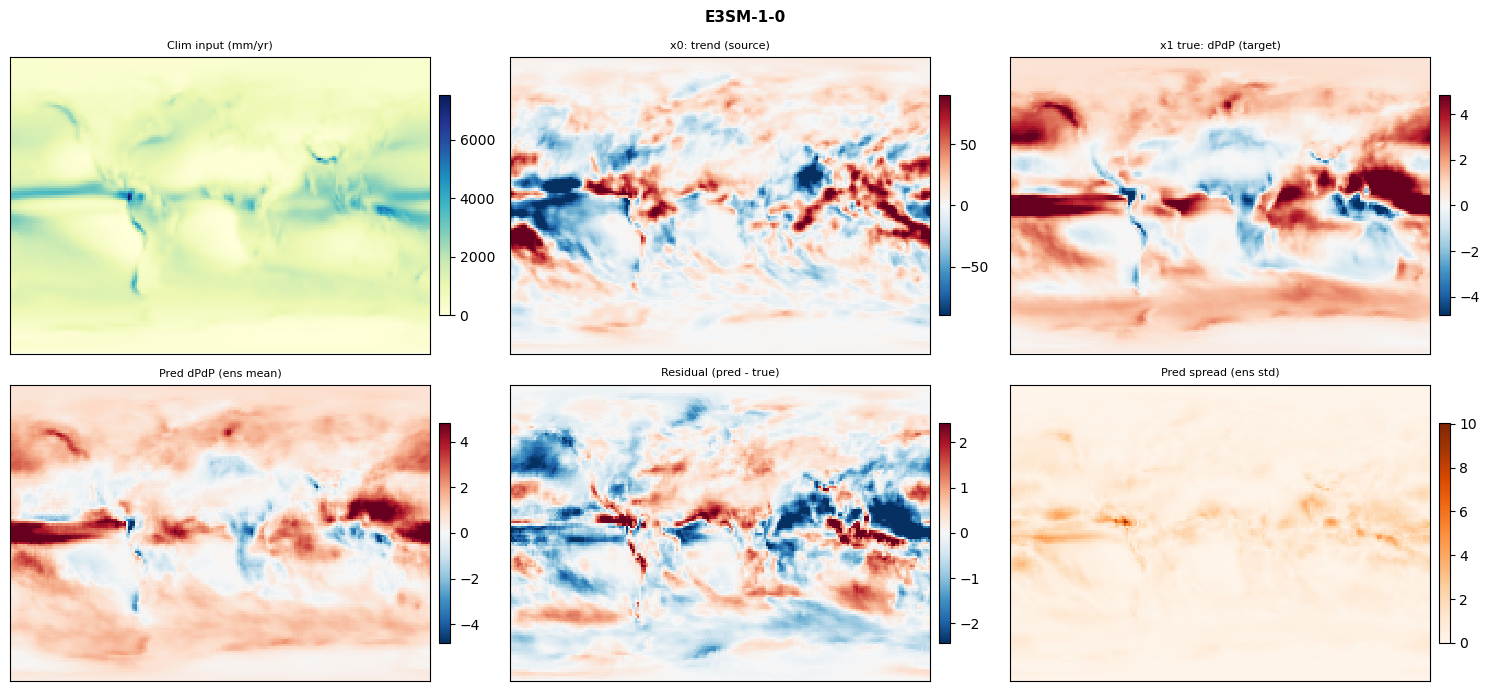

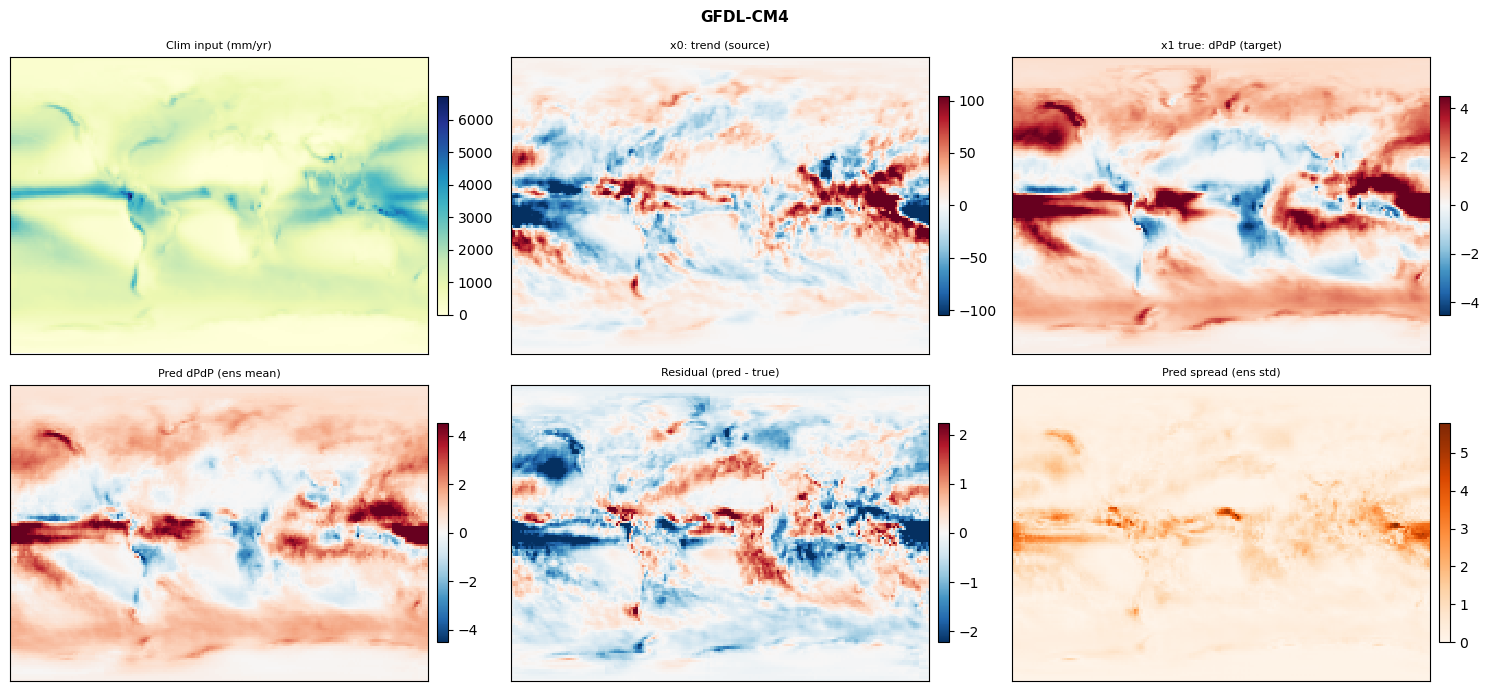


Running inference on eval sources...

Generating summary scatter...
  LOO baseline:  RMSE=0.8756  r=0.667


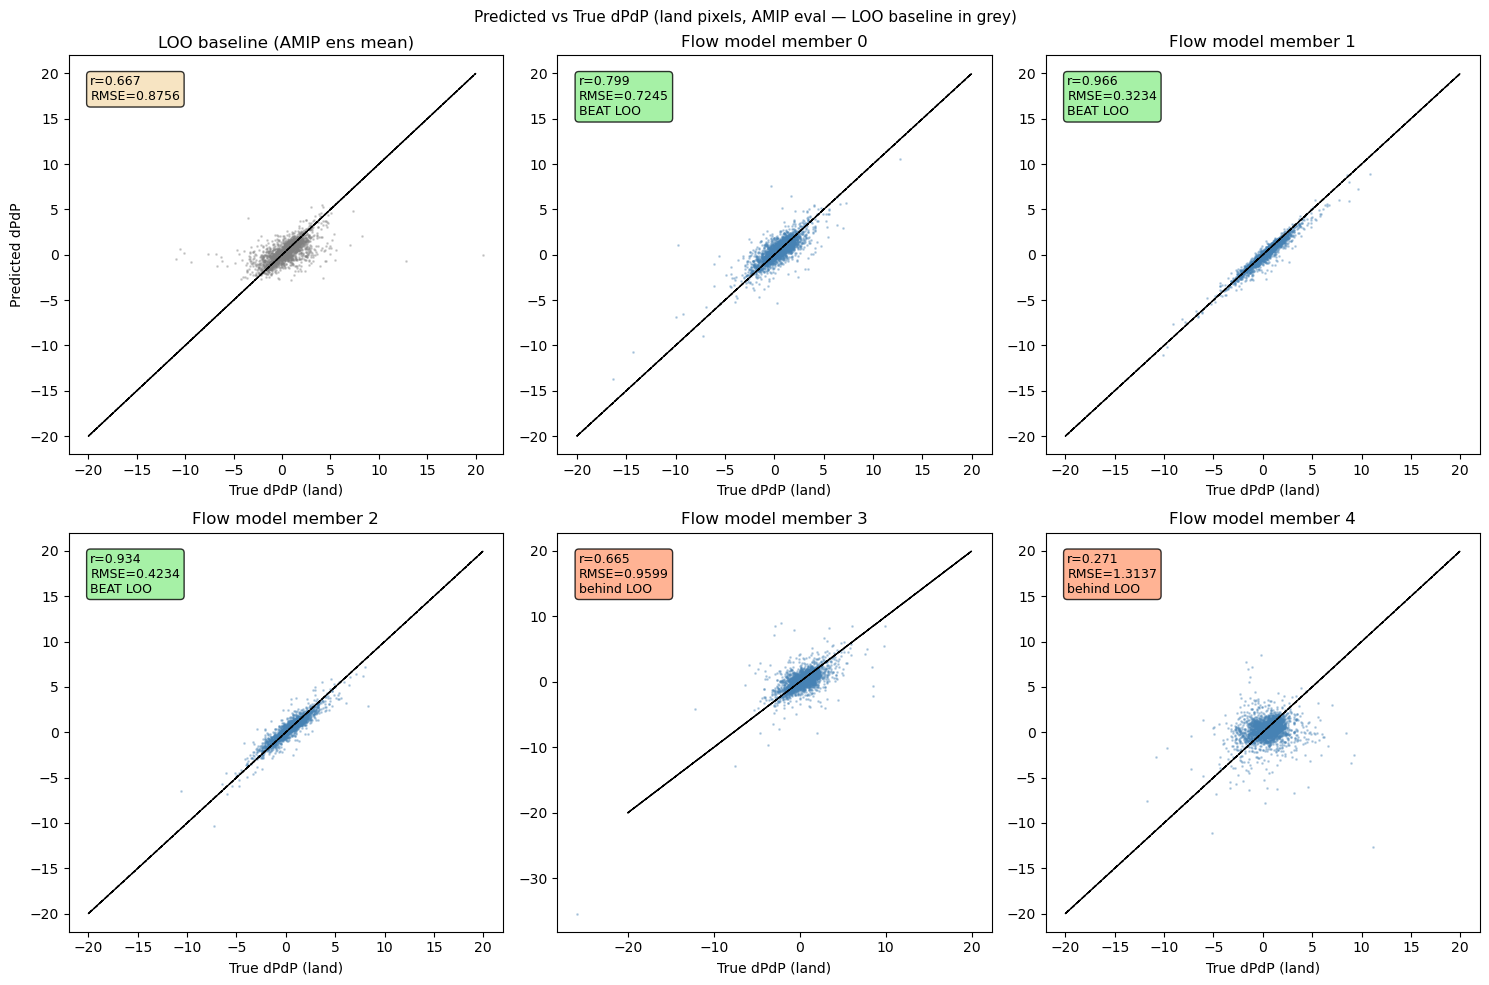


Generating per-model RMSE bar chart...


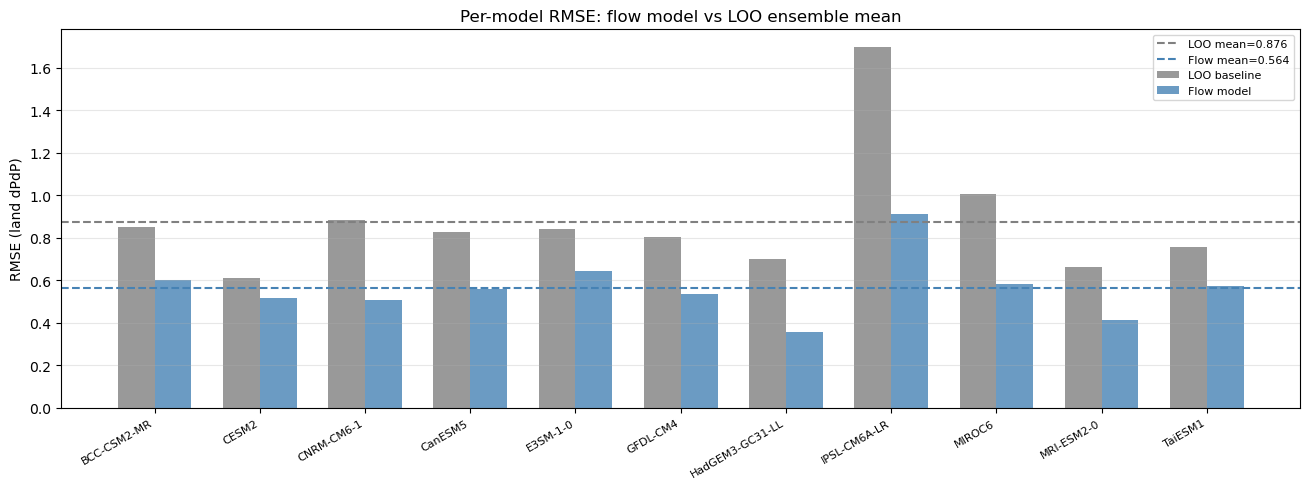


Generating training curves...


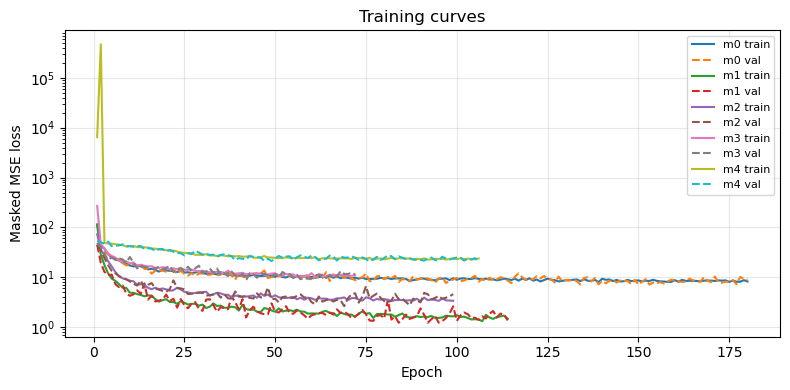


All diagnostics saved to /Users/ewellmeyer/Documents/research/weights/flow_base_unet6R_ch16_land10_oce0.3_aug0.8/diagnostics


In [2]:
"""
check_flow_base.py
==================
Diagnostic script for a trained flow matching base model.

For each ensemble member, loads a sample of AMIP and PPE examples,
runs ODE integration from x0 -> x1_pred, and plots:
  Row 1: clim (conditioning input)
  Row 2: x0   (trend source fed in)
  Row 3: x1_pred  (model prediction, integrated)
  Row 4: x1_true  (target dPdP)
  Row 5: residual (pred - true)

Also plots the ensemble mean prediction and spread across members.

Usage
-----
  python check_flow_base.py

Output
------
  Saves figures to WEIGHTS_DIR / "diagnostics/"
"""
%matplotlib inline

import json
import random
from pathlib import Path

import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import xarray as xr

from flow_models   import Unet6R
from flow_datasets import (model_family, load_nc_field, load_zarr_field,
                            FlowDataset)

# =============================================================================
# configuration — match train_flow_base.py
# =============================================================================

HADGEM_PPE_DIR = Path("/Users/ewellmeyer/Documents/research/HadGEM")
CESM2_PPE_DIR  = Path("/Users/ewellmeyer/Documents/research/CESM2")
AMIP_DIR       = Path("/Users/ewellmeyer/Documents/research/AMIP/processed")
LANDMASK_PATH  = Path("/Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc")
WEIGHTS_DIR    = Path("/Users/ewellmeyer/Documents/research/weights")

BASE_CHANNELS  = 16    
EXPT_NAME      = f"flow_base_unet6R_ch{BASE_CHANNELS}_land10_oce0.3_aug0.8"

WEIGHTS_DIR    = WEIGHTS_DIR / EXPT_NAME
DIAG_DIR       = WEIGHTS_DIR / "diagnostics"
DIAG_DIR.mkdir(exist_ok=True)

N_ENSEMBLE     = 5
N_EXAMPLES     = 6      # number of examples to plot per figure
ODE_STEPS      = 20     # Euler integration steps (more = smoother but slower)
P_DROP         = 0.0    # disable dropout at inference

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# =============================================================================
# ODE integration (Euler)
# =============================================================================

@torch.no_grad()
def integrate(model, x0, clim, steps=20):
    """
    Integrate the learned velocity field from t=0 to t=1 using Euler steps.
    x0, clim : (B, 1, H, W) tensors on DEVICE
    Returns x1_pred : (B, 1, H, W)
    """
    x = x0.clone()
    dt = 1.0 / steps
    for i in range(steps):
        t_val = i * dt
        t     = torch.full((x.shape[0],), t_val, device=DEVICE)
        v     = model(x, clim, t)
        x     = x + v * dt
    return x

# =============================================================================
# load clim stats and models
# =============================================================================

stats_path = WEIGHTS_DIR / "clim_stats.json"
if not stats_path.exists():
    raise FileNotFoundError(f"clim_stats.json not found in {WEIGHTS_DIR}")

with open(stats_path) as f:
    stats = json.load(f)
clim_mean = stats["clim_mean"]
clim_std  = stats["clim_std"]
print(f"Clim stats: mean={clim_mean:.2f}  std={clim_std:.2f} mm/yr")

models = []
for member_idx in range(N_ENSEMBLE):
    ckpt_path = WEIGHTS_DIR / f"best_member{member_idx}.pth"
    if not ckpt_path.exists():
        print(f"  member {member_idx}: checkpoint not found, skipping")
        continue
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = Unet6R(input_channels=2, output_channels=1,
                   base_channels=BASE_CHANNELS,
                   p_drop=P_DROP).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    models.append((member_idx, model))
    print(f"  loaded member {member_idx}  (best val epoch {ckpt['epoch']}  "
          f"val={ckpt['val_loss']:.5f})")

if not models:
    raise RuntimeError("No trained checkpoints found.")

# =============================================================================
# load land mask for display
# =============================================================================

ds_mask  = xr.open_dataset(LANDMASK_PATH)
mask_var = list(ds_mask.data_vars)[0]
land_frac = ds_mask[mask_var].values.astype(np.float32)

# =============================================================================
# load evaluation samples
# =============================================================================

print("\nLoading evaluation data...")
eval_sources = []

# AMIP — use all models (small set, good ground truth)
for clim_path in sorted(AMIP_DIR.glob("AMIP_*_clim.nc")):
    model_name = clim_path.name.replace("AMIP_", "").replace("_clim.nc", "")
    trend_path = AMIP_DIR / f"AMIP_{model_name}_trend.nc"
    dpdp_path  = AMIP_DIR / f"AMIP_{model_name}_dPdP.nc"
    if not trend_path.exists() or not dpdp_path.exists():
        continue
    try:
        clim  = load_nc_field(clim_path,  "pr_clim")
        trend = load_nc_field(trend_path, "pr_trend")
        dpdp  = load_nc_field(dpdp_path,  "dPdP")
        eval_sources.append(dict(name=model_name, clim=clim,
                                 x0=trend, x1=dpdp))
        print(f"  AMIP {model_name}")
    except Exception as e:
        print(f"  WARN {model_name}: {e}")

# sample a few PPE members too
try:
    hg_clim = load_nc_field(HADGEM_PPE_DIR / "GA789_PR_his_rg128.nc", "PR")
    hg_x1   = load_nc_field(HADGEM_PPE_DIR / "GA789_dPdP_rg128.nc",   "dPdP")
    # use a few random members; x0 = zero (no trend available — show clim-only)
    for i in random.sample(range(hg_clim.shape[0]), min(3, hg_clim.shape[0])):
        eval_sources.append(dict(
            name=f"HadGEM3-PPE m{i}",
            clim=hg_clim[i:i+1],
            x0=np.zeros_like(hg_clim[i:i+1]),
            x1=hg_x1[i:i+1],
        ))
    print(f"  HadGEM3-PPE (3 random members, x0=zero)")
except Exception as e:
    print(f"  WARN HadGEM3-PPE: {e}")

print(f"Total eval examples: {len(eval_sources)}")

# =============================================================================
# plotting helpers
# =============================================================================

LAT = np.linspace(-90 + 180/128/2,  90 - 180/128/2, 128)
LON = np.linspace(  0 + 360/192/2, 360 - 360/192/2, 192)

def plot_field(ax, data, title, cmap="RdBu_r", vmin=None, vmax=None,
               symmetric=False):
    if symmetric:
        vmax = vmax or np.nanpercentile(np.abs(data), 98)
        vmin = -vmax
    im = ax.imshow(data, origin="lower", cmap=cmap,
                   vmin=vmin, vmax=vmax,
                   extent=[LON[0], LON[-1], LAT[0], LAT[-1]],
                   aspect="auto", interpolation="nearest")
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    return im

# =============================================================================
# per-example diagnostic: inputs vs outputs per member
# =============================================================================

print("\nGenerating per-example diagnostics...")

examples = eval_sources[:N_EXAMPLES]

for ex in examples:
    name  = ex["name"]
    clim  = ex["clim"][0]    # (H, W)
    x0    = ex["x0"][0]      # (H, W)
    x1    = ex["x1"][0]      # (H, W)

    clim_norm = (clim - clim_mean) / (clim_std + 1e-6)
    clim_norm = np.nan_to_num(clim_norm, nan=0.0)
    x0_in     = np.nan_to_num(x0,       nan=0.0)
    x1_in     = np.nan_to_num(x1,       nan=0.0)

    clim_t = torch.from_numpy(clim_norm[None, None]).float().to(DEVICE)
    x0_t   = torch.from_numpy(x0_in[None, None]).float().to(DEVICE)

    preds = []
    for _, m in models:
        pred = integrate(m, x0_t, clim_t, steps=ODE_STEPS)
        preds.append(pred.cpu().numpy()[0, 0])

    pred_mean = np.mean(preds, axis=0)
    pred_std  = np.std(preds,  axis=0)

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle(f"{name}", fontsize=11, fontweight="bold")

    vdp = np.nanpercentile(np.abs(x1_in), 97)
    plot_field(axes[0, 0], clim,       "Clim input (mm/yr)",
               cmap="YlGnBu", vmin=0)
    plot_field(axes[0, 1], x0_in,      "x0: trend (source)",
               cmap="RdBu_r", symmetric=True)
    plot_field(axes[0, 2], x1_in,      "x1 true: dPdP (target)",
               cmap="RdBu_r", vmin=-vdp, vmax=vdp)
    plot_field(axes[1, 0], pred_mean,  "Pred dPdP (ens mean)",
               cmap="RdBu_r", vmin=-vdp, vmax=vdp)
    plot_field(axes[1, 1], pred_mean - x1_in, "Residual (pred - true)",
               cmap="RdBu_r", symmetric=True)
    plot_field(axes[1, 2], pred_std,   "Pred spread (ens std)",
               cmap="Oranges", vmin=0)

    plt.tight_layout()
    # safe_name = name.replace(" ", "_").replace("/", "-")
    # fig.savefig(DIAG_DIR / f"example_{safe_name}.png", dpi=120,
    #             bbox_inches="tight")
    plt.show()
    # plt.close(fig)
    # print(f"  saved example_{safe_name}.png")

# =============================================================================
# precompute predictions and LOO baseline for all AMIP eval sources
# (PPE examples excluded from LOO since they have no paired ground truth model)
# =============================================================================

print("\nRunning inference on eval sources...")

# only AMIP sources have a meaningful LOO baseline
amip_sources = [s for s in eval_sources if not s["name"].startswith("HadGEM3-PPE")]
all_x1   = []   # true dPdP per AMIP source  (H, W)
all_preds = {mi: [] for mi, _ in models}   # model predictions

for ex in amip_sources:
    clim_norm = np.nan_to_num((ex["clim"][0] - clim_mean) / (clim_std + 1e-6))
    x0_in     = np.nan_to_num(ex["x0"][0])
    x1_in     = np.nan_to_num(ex["x1"][0])
    all_x1.append(x1_in)

    clim_t = torch.from_numpy(clim_norm[None, None]).float().to(DEVICE)
    x0_t   = torch.from_numpy(x0_in[None, None]).float().to(DEVICE)
    for mi, m in models:
        pred = integrate(m, x0_t, clim_t, steps=ODE_STEPS)
        all_preds[mi].append(pred.cpu().numpy()[0, 0])

# LOO baseline: for each model i, predict using mean of all other models' dPdP
# This is the standard benchmark — can we beat the multi-model ensemble mean?
n_amip = len(amip_sources)
loo_preds = []
for i in range(n_amip):
    others = [all_x1[j] for j in range(n_amip) if j != i]
    loo_preds.append(np.mean(others, axis=0))

# =============================================================================
# summary scatter: model predictions vs true, with LOO baseline comparison
# =============================================================================

print("\nGenerating summary scatter...")

land_flat = land_frac.reshape(-1) > 0.5

# compute LOO RMSE over land as the baseline to beat
loo_rmse_vals = []
for i in range(n_amip):
    diff = (loo_preds[i] - all_x1[i]).reshape(-1)[land_flat]
    loo_rmse_vals.append(np.sqrt(np.mean(diff ** 2)))
loo_rmse_mean = np.mean(loo_rmse_vals)
loo_corr_vals = [np.corrcoef(all_x1[i].reshape(-1)[land_flat],
                              loo_preds[i].reshape(-1)[land_flat])[0,1]
                 for i in range(n_amip)]
loo_corr_mean = np.mean(loo_corr_vals)
print(f"  LOO baseline:  RMSE={loo_rmse_mean:.4f}  r={loo_corr_mean:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# first panel: LOO baseline
ax = axes[0]
loo_true = np.concatenate([all_x1[i].reshape(-1)[land_flat] for i in range(n_amip)])
loo_pred = np.concatenate([loo_preds[i].reshape(-1)[land_flat] for i in range(n_amip)])
idx = np.random.choice(len(loo_true), size=min(5000, len(loo_true)), replace=False)
ax.scatter(loo_true[idx], loo_pred[idx], s=1, alpha=0.3, color="gray")
lims = [-20, 20, -20, 20]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("True dPdP (land)"); ax.set_ylabel("Predicted dPdP")
ax.set_title("LOO baseline (AMIP ens mean)")
ax.text(0.05, 0.95, f"r={loo_corr_mean:.3f}\nRMSE={loo_rmse_mean:.4f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
# ax.set_xlim(lims); ax.set_ylim(lims)

# remaining panels: flow model members
for (mi, m), ax in zip(models, axes[1:]):
    true_vals = np.concatenate([all_x1[i].reshape(-1)[land_flat]
                                 for i in range(n_amip)])
    pred_vals = np.concatenate([all_preds[mi][i].reshape(-1)[land_flat]
                                 for i in range(n_amip)])
    idx = np.random.choice(len(true_vals), size=min(5000, len(true_vals)), replace=False)
    ax.scatter(true_vals[idx], pred_vals[idx], s=1, alpha=0.3, color="steelblue")
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("True dPdP (land)")
    ax.set_title(f"Flow model member {mi}")

    corr = np.corrcoef(true_vals, pred_vals)[0, 1]
    rmse = np.sqrt(np.mean((pred_vals - true_vals) ** 2))
    beat = "BEAT" if rmse < loo_rmse_mean else "behind"
    color = "lightgreen" if rmse < loo_rmse_mean else "lightsalmon"
    ax.text(0.05, 0.95,
            f"r={corr:.3f}\nRMSE={rmse:.4f}\n{beat} LOO",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor=color, alpha=0.8))

plt.suptitle("Predicted vs True dPdP (land pixels, AMIP eval — LOO baseline in grey)",
             fontsize=11)
plt.tight_layout()
plt.show()
# fig.savefig(DIAG_DIR / "scatter_pred_vs_true.png", dpi=120, bbox_inches="tight")
# plt.close(fig)
# print("  saved scatter_pred_vs_true.png")

# =============================================================================
# per-model LOO bar chart: model RMSE vs LOO baseline per AMIP model
# =============================================================================

print("\nGenerating per-model RMSE bar chart...")

model_names = [s["name"] for s in amip_sources]
ens_pred_mean = [np.mean([all_preds[mi][i] for mi, _ in models], axis=0)
                 for i in range(n_amip)]
ens_rmse = [np.sqrt(np.mean(
                ((ens_pred_mean[i] - all_x1[i]).reshape(-1)[land_flat]) ** 2))
            for i in range(n_amip)]

x = np.arange(n_amip)
width = 0.35
fig, ax = plt.subplots(figsize=(max(8, n_amip * 1.2), 5))
ax.bar(x - width/2, loo_rmse_vals,  width, label="LOO baseline", color="gray",   alpha=0.8)
ax.bar(x + width/2, ens_rmse,       width, label="Flow model",   color="steelblue", alpha=0.8)
ax.axhline(loo_rmse_mean, color="gray",      lw=1.5, linestyle="--", label=f"LOO mean={loo_rmse_mean:.3f}")
ax.axhline(np.mean(ens_rmse), color="steelblue", lw=1.5, linestyle="--",
           label=f"Flow mean={np.mean(ens_rmse):.3f}")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("RMSE (land dPdP)")
ax.set_title("Per-model RMSE: flow model vs LOO ensemble mean")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
# fig.savefig(DIAG_DIR / "rmse_vs_loo_per_model.png", dpi=120, bbox_inches="tight")
# plt.close(fig)
# print("  saved rmse_vs_loo_per_model.png")

# =============================================================================
# training curves
# =============================================================================

print("\nGenerating training curves...")
fig, ax = plt.subplots(figsize=(8, 4))

for member_idx, _ in models:
    log_path = WEIGHTS_DIR / f"log_member{member_idx}.json"
    if not log_path.exists():
        continue
    with open(log_path) as f:
        log = json.load(f)
    epochs     = [e["epoch"]  for e in log]
    train_loss = [e["train"]  for e in log]
    val_loss   = [e["val"]    for e in log]
    ax.plot(epochs, train_loss, lw=1.5, label=f"m{member_idx} train")
    ax.plot(epochs, val_loss,   lw=1.5, linestyle="--",
            label=f"m{member_idx} val")

ax.set_xlabel("Epoch")
ax.set_ylabel("Masked MSE loss")
ax.set_title("Training curves")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# fig.savefig(DIAG_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
# plt.close(fig)
# print("  saved training_curves.png")

print(f"\nAll diagnostics saved to {DIAG_DIR}")